# PyTorch可视化实战：Matplotlib完全指南

## 1. 基础设置

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch

# # 设置中文字体（如果需要）
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']  
plt.rcParams['axes.unicode_minus'] = False

## 2. 基本图表类型

### 2.1 折线图 - 用于损失曲线和准确率

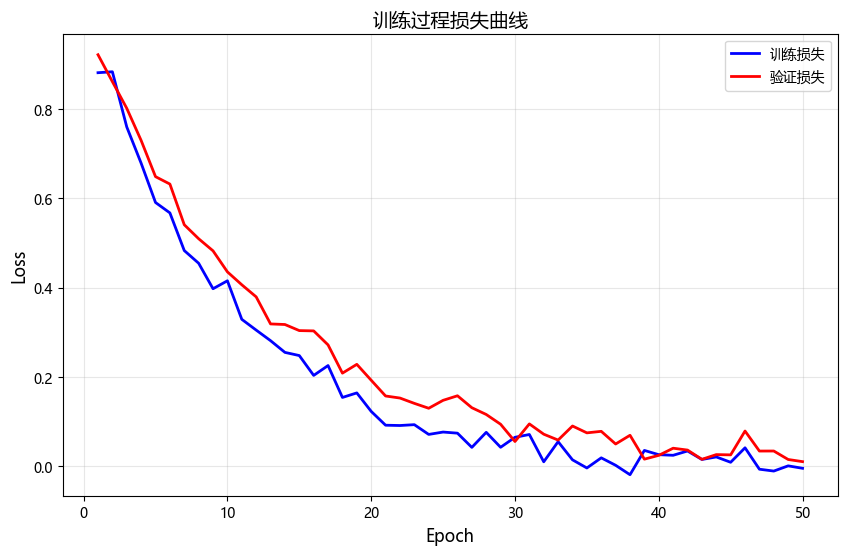

In [3]:
# 模拟训练过程
epochs = range(1, 51)
train_loss = np.exp(-np.array(epochs)/10) + np.random.normal(0, 0.02, 50)
val_loss = np.exp(-np.array(epochs)/12) + np.random.normal(0, 0.02, 50)

plt.figure(figsize=(10, 6))
plt.plot(epochs, train_loss, 'b-', label='训练损失', linewidth=2)
plt.plot(epochs, val_loss, 'r-', label='验证损失', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('训练过程损失曲线', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### 2.2 散点图 - 用于数据分布可视化

`uv add scikit-learn`或者`pip install scikit-learn`

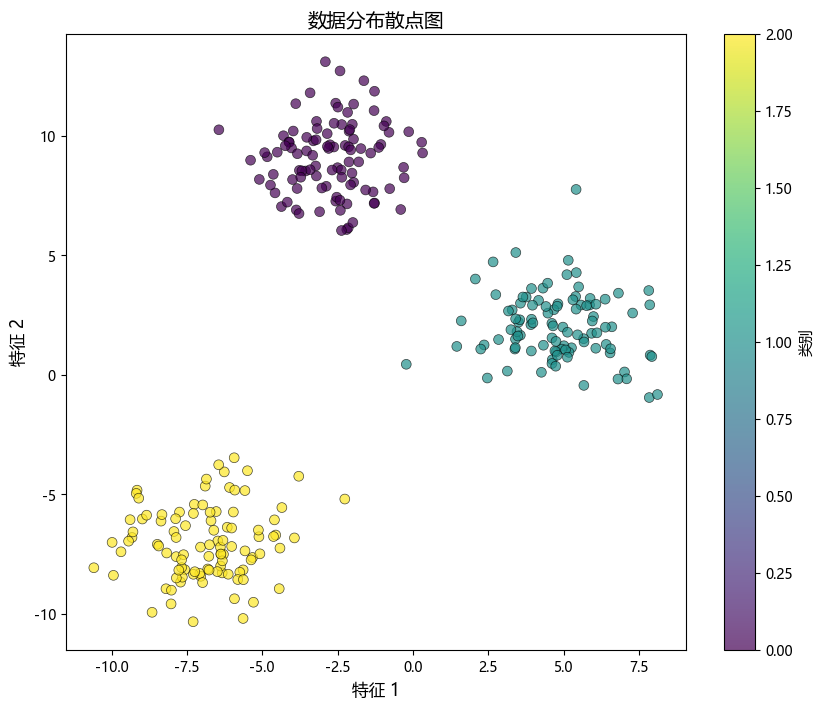

In [4]:
from sklearn.datasets import make_blobs

X, y = make_blobs(n_samples=300, centers=3, n_features=2, 
                  cluster_std=1.5, random_state=42)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', 
                      s=50, alpha=0.7, edgecolors='black', linewidth=0.5)
plt.colorbar(scatter, label='类别')
plt.xlabel('特征 1', fontsize=12)
plt.ylabel('特征 2', fontsize=12)
plt.title('数据分布散点图', fontsize=14)
plt.show()

### 2.3 直方图 - 用于参数分布分析

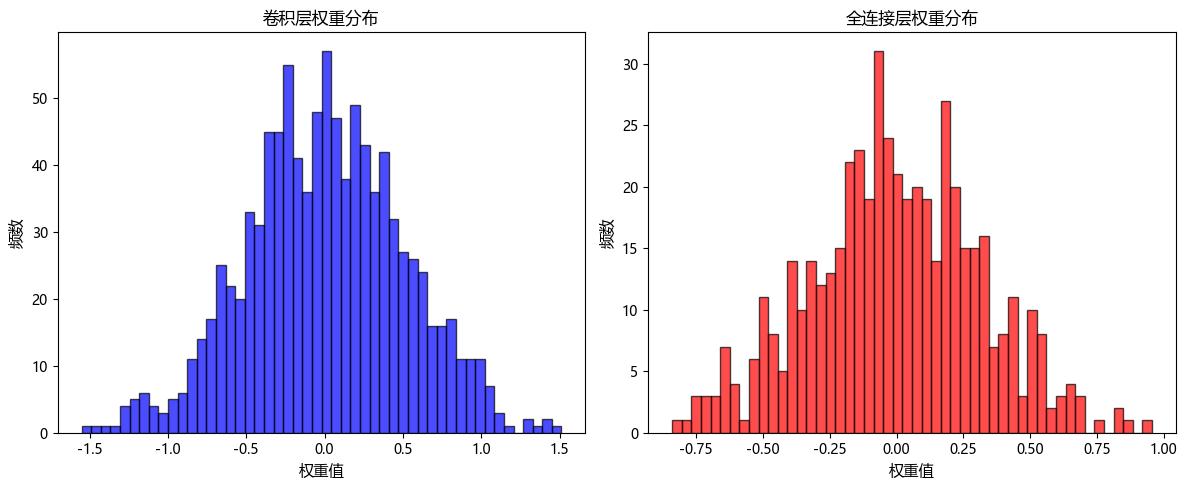

In [5]:
# 模拟 PyTorch 模型参数分布
torch.manual_seed(42)
conv_weights = torch.randn(1000) * 0.5
fc_weights = torch.randn(500) * 0.3

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(conv_weights.numpy(), bins=50, alpha=0.7, color='blue', edgecolor='black')
plt.xlabel('权重值', fontsize=11)
plt.ylabel('频数', fontsize=11)
plt.title('卷积层权重分布', fontsize=12)

plt.subplot(1, 2, 2)
plt.hist(fc_weights.numpy(), bins=50, alpha=0.7, color='red', edgecolor='black')
plt.xlabel('权重值', fontsize=11)
plt.ylabel('频数', fontsize=11)
plt.title('全连接层权重分布', fontsize=12)

plt.tight_layout()
plt.show()

## 3. 常用可视化模式

### 3.1 损失和准确率双轴图

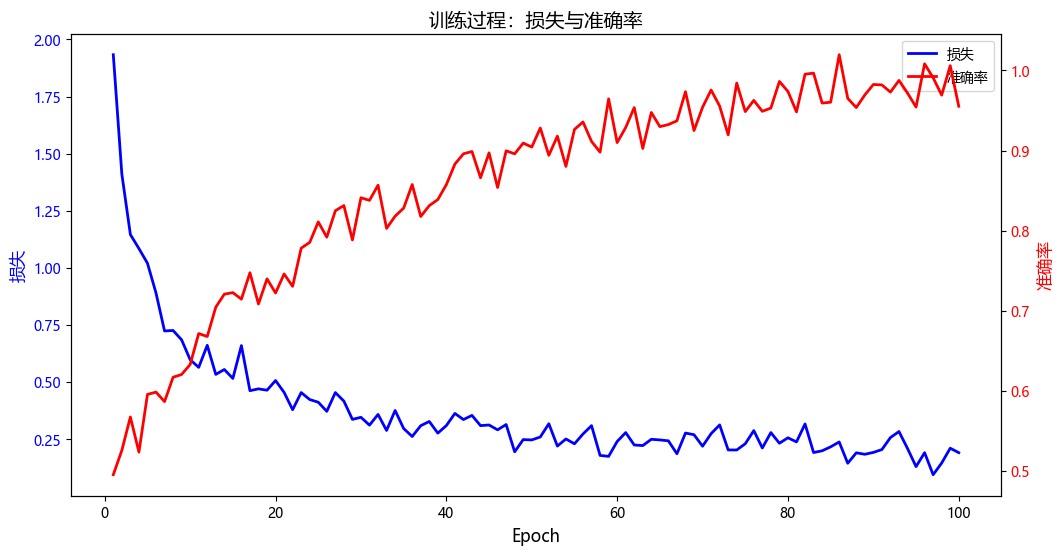

In [6]:
# 创建模拟数据
epochs = np.arange(1, 101)
loss = 2 / np.sqrt(epochs) + np.random.normal(0, 0.05, 100)
accuracy = 1 - 0.5 * np.exp(-epochs/30) + np.random.normal(0, 0.02, 100)

fig, ax1 = plt.subplots(figsize=(12, 6))

# 左轴：损失
ax1.plot(epochs, loss, 'b-', label='损失', linewidth=2)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('损失', color='b', fontsize=12)
ax1.tick_params(axis='y', labelcolor='b')

# 右轴：准确率
ax2 = ax1.twinx()
ax2.plot(epochs, accuracy, 'r-', label='准确率', linewidth=2)
ax2.set_ylabel('准确率', color='r', fontsize=12)
ax2.tick_params(axis='y', labelcolor='r')

plt.title('训练过程：损失与准确率', fontsize=14)

# 合并图例
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.show()

### 3.2 多子图对比不同模型

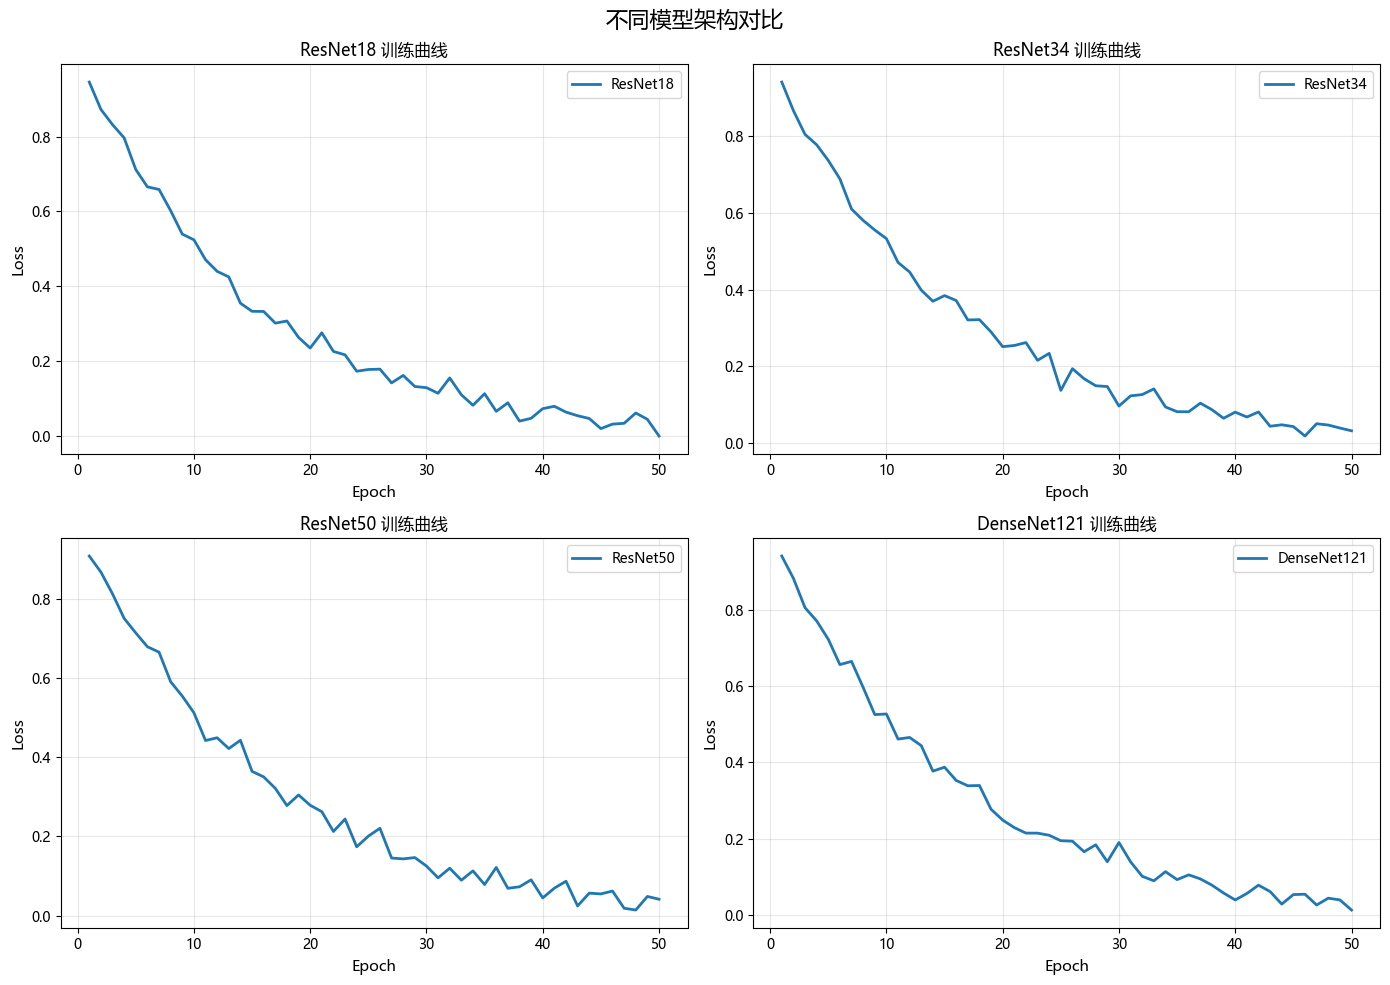

In [7]:
# 模拟多个模型的训练结果
models = ['ResNet18', 'ResNet34', 'ResNet50', 'DenseNet121']
epochs = np.arange(1, 51)

np.random.seed(42)
results = {}
for model in models:
    base_loss = np.exp(-epochs/15)
    results[model] = base_loss + np.random.normal(0, 0.02, 50)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for idx, (model, loss) in enumerate(results.items()):
    axes[idx].plot(epochs, loss, linewidth=2, label=model)
    axes[idx].set_xlabel('Epoch', fontsize=11)
    axes[idx].set_ylabel('Loss', fontsize=11)
    axes[idx].set_title(f'{model} 训练曲线', fontsize=12)
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.suptitle('不同模型架构对比', fontsize=16)
plt.tight_layout()
plt.show()

## 4. PyTorch 集成示例

### 4.1 实时绘制训练曲线

In [ ]:
class LivePlotter:
    def __init__(self):
        plt.ion()  # 交互模式
        self.fig, (self.ax1, self.ax2) = plt.subplots(1, 2, figsize=(14, 5))
        self.train_losses = []
        self.val_losses = []
        self.train_accs = []
        self.val_accs = []
        
    def update(self, epoch, train_loss, val_loss, train_acc, val_acc):
        self.train_losses.append(train_loss)
        self.val_losses.append(val_loss)
        self.train_accs.append(train_acc)
        self.val_accs.append(val_acc)
        
        # 清空并重绘
        self.ax1.clear()
        self.ax2.clear()
        
        # 损失图
        self.ax1.plot(self.train_losses, 'b-', label='训练损失', linewidth=2)
        self.ax1.plot(self.val_losses, 'r-', label='验证损失', linewidth=2)
        self.ax1.set_xlabel('Epoch')
        self.ax1.set_ylabel('Loss')
        self.ax1.set_title('损失曲线')
        self.ax1.legend()
        self.ax1.grid(True, alpha=0.3)
        
        # 准确率图
        self.ax2.plot(self.train_accs, 'b-', label='训练准确率', linewidth=2)
        self.ax2.plot(self.val_accs, 'r-', label='验证准确率', linewidth=2)
        self.ax2.set_xlabel('Epoch')
        self.ax2.set_ylabel('Accuracy (%)')
        self.ax2.set_title('准确率曲线')
        self.ax2.legend()
        self.ax2.grid(True, alpha=0.3)
        
        plt.suptitle(f'Epoch {epoch}', fontsize=12)
        plt.pause(0.01)
    
    def close(self):
        plt.ioff()
        plt.show()

# 使用示例
plotter = LivePlotter()
for epoch in range(1, 51):
    # 模拟训练过程
    train_loss = 2 / np.sqrt(epoch) + np.random.normal(0, 0.05)
    val_loss = 2.2 / np.sqrt(epoch) + np.random.normal(0, 0.05)
    train_acc = 100 * (1 - np.exp(-epoch/20))
    val_acc = 100 * (1 - np.exp(-epoch/25))
    
    plotter.update(epoch, train_loss, val_loss, train_acc, val_acc)

plotter.close()

### 4.2 可视化卷积核

In [9]:
def visualize_filters(model, layer_name='conv1', num_filters=16):
    """可视化卷积层过滤器"""
    # 获取指定层的权重
    for name, param in model.named_parameters():
        if layer_name in name and 'weight' in name:
            filters = param.data.cpu().numpy()
            break
    
    # 限制显示数量
    n_filters = min(num_filters, filters.shape[0])
    
    # 计算子图布局
    n_cols = 4
    n_rows = (n_filters + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 3*n_rows))
    axes = axes.flatten() if n_rows > 1 else [axes]
    
    for i in range(n_filters):
        # 归一化以便显示
        filter_img = filters[i, 0]  # 第一个通道
        filter_img = (filter_img - filter_img.min()) / (filter_img.max() - filter_img.min())
        
        axes[i].imshow(filter_img, cmap='viridis')
        axes[i].set_title(f'Filter {i+1}')
        axes[i].axis('off')
    
    # 隐藏多余的子图
    for i in range(n_filters, len(axes)):
        axes[i].axis('off')
    
    plt.suptitle(f'卷积层 {layer_name} 可视化', fontsize=14)
    plt.tight_layout()
    plt.show()

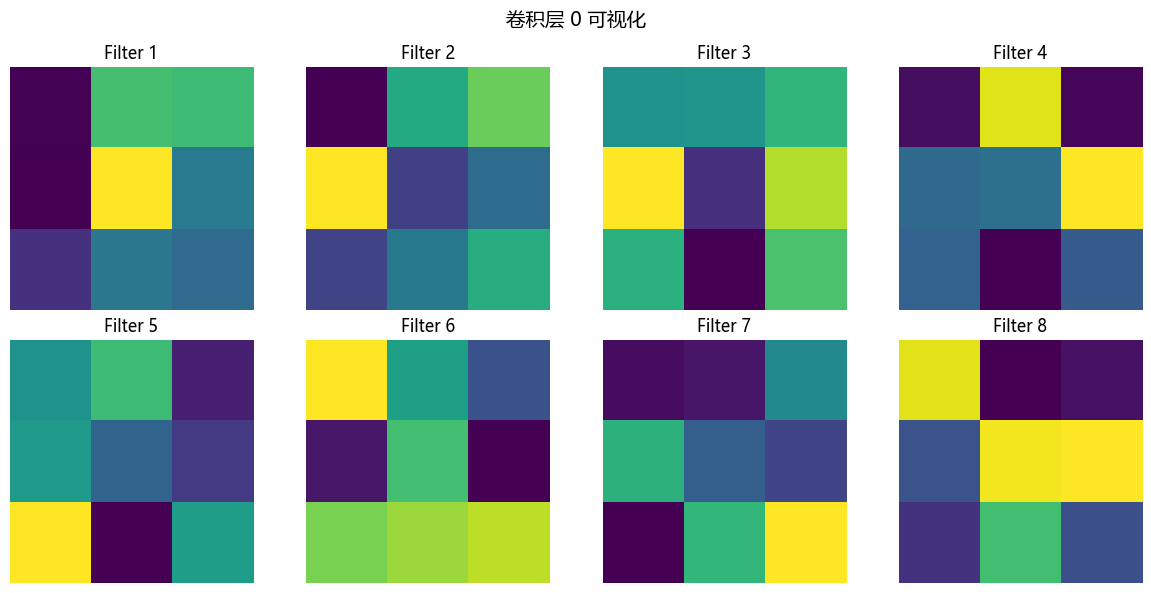

In [10]:
# 创建最简单的模型
model = torch.nn.Sequential(torch.nn.Conv2d(3, 8, 3))

# 调用可视化（需要先定义 visualize_filters 函数）
visualize_filters(model, '0', 8)  # Sequential 的层名是 '0'

In [11]:
### 4.3 特征图可视化

In [12]:
def visualize_feature_maps(feature_maps, num_maps=16):
    """可视化特征图输出"""
    if isinstance(feature_maps, torch.Tensor):
        feature_maps = feature_maps.cpu().detach().numpy()
    
    # 假设输入格式: [batch, channels, height, width]
    if len(feature_maps.shape) == 4:
        feature_maps = feature_maps[0]  # 取第一个batch
    
    n_maps = min(num_maps, feature_maps.shape[0])
    n_cols = 4
    n_rows = (n_maps + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 3*n_rows))
    axes = axes.flatten() if n_rows > 1 else [axes]
    
    for i in range(n_maps):
        fm = feature_maps[i]
        # 归一化
        fm = (fm - fm.min()) / (fm.max() - fm.min() + 1e-8)
        
        axes[i].imshow(fm, cmap='hot')
        axes[i].set_title(f'通道 {i+1}')
        axes[i].axis('off')
    
    for i in range(n_maps, len(axes)):
        axes[i].axis('off')
    
    plt.suptitle('特征图可视化', fontsize=14)
    plt.tight_layout()
    plt.show()

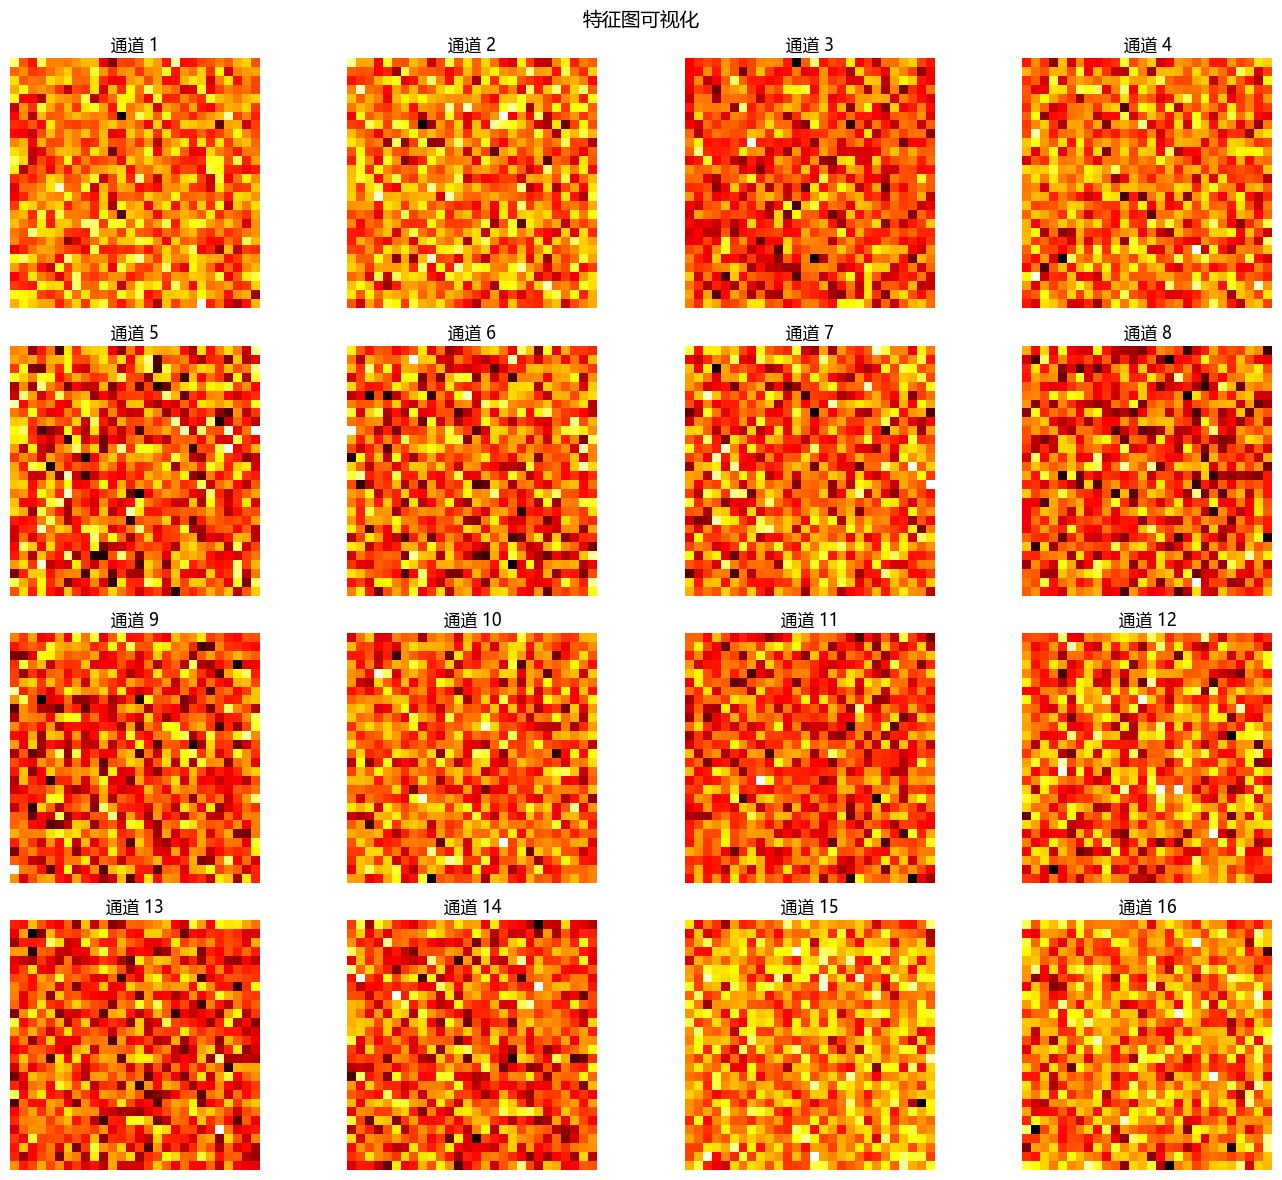

In [13]:
# 创建一个简单的特征图用于测试
test_feature_maps = torch.randn(32, 28, 28)  # 32个通道，尺寸 28x28
visualize_feature_maps(test_feature_maps, num_maps=16)

## 5. 高级可视化技巧

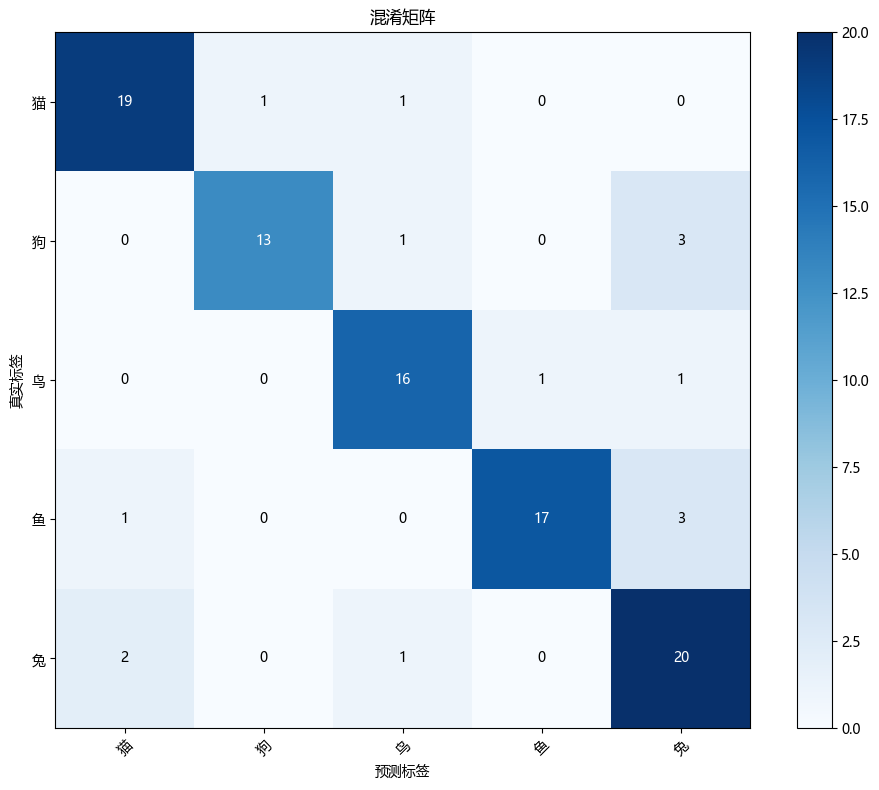

In [14]:
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix(y_true, y_pred, classes):
    """绘制混淆矩阵"""
    cm = confusion_matrix(y_true, y_pred)
    
    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
    ax.figure.colorbar(im, ax=ax)
    
    # 设置标签
    ax.set(xticks=np.arange(cm.shape[1]),
           yticks=np.arange(cm.shape[0]),
           xticklabels=classes, yticklabels=classes,
           title='混淆矩阵',
           ylabel='真实标签',
           xlabel='预测标签')
    
    # 旋转x轴标签
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
    
    # 添加数值文本
    thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm[i, j], 'd'),
                   ha="center", va="center",
                   color="white" if cm[i, j] > thresh else "black")
    
    plt.tight_layout()
    plt.show()

# 示例
y_true = np.random.randint(0, 5, 100)
y_pred = y_true.copy()
# 添加一些错误
noise_idx = np.random.choice(100, 20, replace=False)
y_pred[noise_idx] = np.random.randint(0, 5, 20)
classes = ['猫', '狗', '鸟', '鱼', '兔']

plot_confusion_matrix(y_true, y_pred, classes)

### 5.2 3D 可视化决策边界

In [15]:
from mpl_toolkits.mplot3d import Axes3D

def plot_3d_decision_boundary(model, X, y):
    """3D 决策边界可视化（适用于2特征问题）"""
    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    # 创建网格
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 50),
                         np.linspace(y_min, y_max, 50))
    
    # 预测
    grid_points = np.c_[xx.ravel(), yy.ravel()]
    with torch.no_grad():
        grid_tensor = torch.FloatTensor(grid_points)
        Z = model(grid_tensor).argmax(dim=1).numpy()
    Z = Z.reshape(xx.shape)
    
    # 绘制决策面
    ax.plot_surface(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    
    # 绘制数据点
    scatter = ax.scatter(X[:, 0], X[:, 1], y, c=y, cmap='coolwarm', 
                        s=50, edgecolors='black', linewidth=0.5)
    
    ax.set_xlabel('特征 1')
    ax.set_ylabel('特征 2')
    ax.set_zlabel('类别')
    ax.set_title('3D 决策边界可视化')
    
    plt.show()

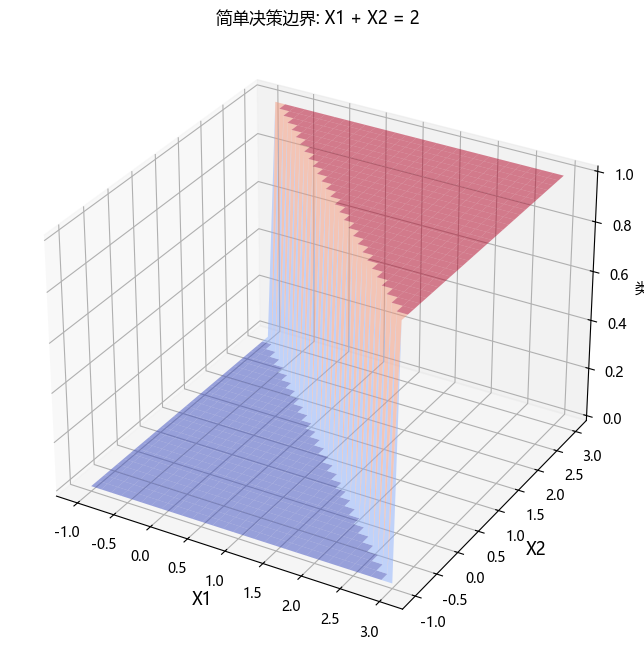

In [18]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D


# ax.set_xlabel('X1', fontsize=12)
# ax.set_ylabel('X2', fontsize=12)

# 最简单的测试：直接可视化一个已知的决策边界
def quick_test():
    # 创建一个简单的线性模型
    class SimpleModel(torch.nn.Module):
        def forward(self, x):
            # 决策边界: x1 + x2 - 2 = 0
            return torch.cat([torch.zeros_like(x[:, :1]), 
                             (x[:, 0:1] + x[:, 1:2] - 2)], dim=1)
    
    model = SimpleModel()
    
    # 生成网格数据
    xx, yy = np.meshgrid(np.linspace(-1, 3, 30),
                         np.linspace(-1, 3, 30))
    
    # 预测
    grid_points = np.c_[xx.ravel(), yy.ravel()]
    with torch.no_grad():
        grid_tensor = torch.FloatTensor(grid_points)
        Z = model(grid_tensor).argmax(dim=1).numpy()
    Z = Z.reshape(xx.shape)
    
    # 3D可视化
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    ax.plot_surface(xx, yy, Z, alpha=0.5, cmap='coolwarm')
    # ax.set_xlabel('X₁')
    # ax.set_ylabel('X₂')

    ax.set_xlabel('X1', fontsize=12)
    ax.set_ylabel('X2', fontsize=12)
    
    
    ax.set_zlabel('类别')
    ax.set_title('简单决策边界: X1 + X2 = 2')
    plt.show()

quick_test()

## 6. 保存和导出

In [ ]:
# 保存图片
plt.savefig('training_curve.png', dpi=300, bbox_inches='tight')

# 保存为不同格式
plt.savefig('figure.pdf', format='pdf', bbox_inches='tight')
plt.savefig('figure.svg', format='svg')

# 多页PDF（适合保存多个epoch的中间结果）
from matplotlib.backends.backend_pdf import PdfPages

with PdfPages('training_progress.pdf') as pdf:
    for epoch in range(10):
        plt.figure()
        plt.plot(np.random.randn(100).cumsum())
        plt.title(f'Epoch {epoch+1}')
        pdf.savefig()
        plt.close()